# Chunking y Bases de Datos Vectoriales

## Introducción

Este notebook cubre dos conceptos fundamentales para sistemas RAG (Retrieval-Augmented Generation):

1. **Chunking**: División inteligente de documentos en fragmentos manejables
2. **Bases de Datos Vectoriales**: Almacenamiento y búsqueda eficiente de embeddings

### Objetivos:
- Entender diferentes estrategias de chunking
- Implementar técnicas de división de texto
- Trabajar con bases de datos vectoriales (FAISS, ChromaDB)
- Generar y almacenar embeddings
- Realizar búsquedas de similitud

## Instalación de Librerías

In [1]:
# Instalación de librerías necesarias
!pip install numpy pandas matplotlib sentence-transformers faiss-cpu chromadb tiktoken --quiet

# Importaciones
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
import re
import textwrap
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Librerías básicas importadas correctamente")

✅ Librerías básicas importadas correctamente


---
# 📄 PARTE 1: Técnicas de Chunking

## ¿Qué es Chunking?

**Chunking** es el proceso de dividir documentos largos en fragmentos más pequeños y manejables. Es crucial porque:

1. **Límites de tokens**: Los modelos de lenguaje tienen límites de contexto
2. **Precisión de búsqueda**: Fragmentos más pequeños permiten recuperación más precisa
3. **Eficiencia**: Procesamiento y búsqueda más rápidos
4. **Contexto relevante**: Evita incluir información irrelevante

## Objetivos del Chunking:
- Mantener coherencia semántica
- Preservar contexto importante
- Optimizar tamaño para el modelo
- Evitar cortes en medio de ideas

In [2]:
# Documento de ejemplo para demostración
sample_document = """La inteligencia artificial (IA) es una rama de la informática que se dedica a crear sistemas capaces de realizar tareas que normalmente requieren inteligencia humana. Estas tareas incluyen el reconocimiento de voz, la visión por computadora, la toma de decisiones y la traducción de idiomas.

El aprendizaje automático (Machine Learning) es un subcampo de la IA que permite a los sistemas aprender y mejorar automáticamente a partir de la experiencia sin ser programados explícitamente. Los algoritmos de machine learning construyen modelos matemáticos basados en datos de entrenamiento para hacer predicciones o tomar decisiones.

El aprendizaje profundo (Deep Learning) es un tipo especializado de machine learning que utiliza redes neuronales artificiales con múltiples capas. Estas redes pueden aprender representaciones de datos con múltiples niveles de abstracción. El deep learning ha revolucionado campos como el reconocimiento de imágenes y el procesamiento del lenguaje natural.

Los modelos de lenguaje grandes (LLMs) como GPT son ejemplos de sistemas de deep learning entrenados en vastas cantidades de texto. Estos modelos pueden generar texto coherente, responder preguntas, traducir idiomas y realizar muchas otras tareas relacionadas con el lenguaje. Los LLMs han transformado la forma en que interactuamos con las computadoras.

La generación aumentada por recuperación (RAG) es una técnica que combina la recuperación de información con modelos de lenguaje. RAG primero busca información relevante en una base de datos y luego usa esa información para generar respuestas más precisas y fundamentadas. Esta técnica es especialmente útil para aplicaciones que requieren conocimiento actualizado o específico de dominio.
"""

print("📄 Documento de ejemplo cargado")
print(f"Longitud: {len(sample_document)} caracteres")
print(f"Palabras: {len(sample_document.split())} palabras")
print(f"Párrafos: {len(sample_document.split(chr(10) + chr(10)))} párrafos")

📄 Documento de ejemplo cargado
Longitud: 1736 caracteres
Palabras: 250 palabras
Párrafos: 5 párrafos


In [3]:
print(sample_document)

La inteligencia artificial (IA) es una rama de la informática que se dedica a crear sistemas capaces de realizar tareas que normalmente requieren inteligencia humana. Estas tareas incluyen el reconocimiento de voz, la visión por computadora, la toma de decisiones y la traducción de idiomas.

El aprendizaje automático (Machine Learning) es un subcampo de la IA que permite a los sistemas aprender y mejorar automáticamente a partir de la experiencia sin ser programados explícitamente. Los algoritmos de machine learning construyen modelos matemáticos basados en datos de entrenamiento para hacer predicciones o tomar decisiones.

El aprendizaje profundo (Deep Learning) es un tipo especializado de machine learning que utiliza redes neuronales artificiales con múltiples capas. Estas redes pueden aprender representaciones de datos con múltiples niveles de abstracción. El deep learning ha revolucionado campos como el reconocimiento de imágenes y el procesamiento del lenguaje natural.

Los modelo

---
## 1️⃣ Chunking por Carácter Fijo

### Descripción:
Divide el texto en fragmentos de tamaño fijo basado en el número de caracteres.

### Ventajas:
- Simple de implementar
- Predecible en tamaño
- Rápido

### Desventajas:
- Puede cortar en medio de palabras o frases
- No respeta estructura semántica
- Pierde contexto

In [4]:
def chunk_by_characters(text: str, chunk_size: int = 200, overlap: int = 50) -> List[str]:
    """
    Divide texto en chunks de tamaño fijo con overlap.

    Args:
        text: Texto a dividir
        chunk_size: Tamaño de cada chunk en caracteres
        overlap: Número de caracteres que se solapan entre chunks

    Returns:
        Lista de chunks
    """
    chunks = []
    start = 0

    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start = end - overlap

    return chunks

# Aplicar chunking por caracteres
char_chunks = chunk_by_characters(sample_document, chunk_size=200, overlap=50)

print(f"\n📊 Chunking por Caracteres:")
print(f"  Total de chunks: {len(char_chunks)}")
print(f"  Tamaño promedio: {np.mean([len(c) for c in char_chunks]):.1f} caracteres\n")

# Mostrar primeros 3 chunks
for i, chunk in enumerate(char_chunks[:3], 1):
    print(f"Chunk {i}:")
    print(f"{chunk}...")
    print(f"Longitud: {len(chunk)} caracteres\n")


📊 Chunking por Caracteres:
  Total de chunks: 12
  Tamaño promedio: 190.5 caracteres

Chunk 1:
La inteligencia artificial (IA) es una rama de la informática que se dedica a crear sistemas capaces de realizar tareas que normalmente requieren inteligencia humana. Estas tareas incluyen el reconoci...
Longitud: 200 caracteres

Chunk 2:
ligencia humana. Estas tareas incluyen el reconocimiento de voz, la visión por computadora, la toma de decisiones y la traducción de idiomas.

El aprendizaje automático (Machine Learning) es un subcam...
Longitud: 200 caracteres

Chunk 3:
ndizaje automático (Machine Learning) es un subcampo de la IA que permite a los sistemas aprender y mejorar automáticamente a partir de la experiencia sin ser programados explícitamente. Los algoritmo...
Longitud: 200 caracteres



---
## 2️⃣ Chunking por Palabras

### Descripción:
Divide el texto basándose en el número de palabras, respetando límites de palabras.

### Ventajas:
- Respeta límites de palabras
- Más legible que por caracteres
- Mejor para análisis lingüístico

### Desventajas:
- Puede cortar en medio de frases
- No respeta estructura semántica completa
- Tamaño variable en caracteres

In [5]:
def chunk_by_words(text: str, chunk_size: int = 50, overlap: int = 10) -> List[str]:
    """
    Divide texto en chunks basados en número de palabras.

    Args:
        text: Texto a dividir
        chunk_size: Número de palabras por chunk
        overlap: Número de palabras de overlap

    Returns:
        Lista de chunks
    """
    words = text.split()
    chunks = []

    for i in range(0, len(words), chunk_size - overlap):
        chunk_words = words[i:i + chunk_size]
        chunks.append(' '.join(chunk_words))

        if i + chunk_size >= len(words):
            break

    return chunks

# Aplicar chunking por palabras
word_chunks = chunk_by_words(sample_document, chunk_size=50, overlap=10)

print(f"\n📊 Chunking por Palabras:")
print(f"  Total de chunks: {len(word_chunks)}")
print(f"  Palabras promedio: {np.mean([len(c.split()) for c in word_chunks]):.1f} palabras\n")

# Mostrar primeros 2 chunks
for i, chunk in enumerate(word_chunks[:2], 1):
    print(f"Chunk {i}:")
    print(f"{chunk}")
    print(f"Palabras: {len(chunk.split())}\n")


📊 Chunking por Palabras:
  Total de chunks: 6
  Palabras promedio: 50.0 palabras

Chunk 1:
La inteligencia artificial (IA) es una rama de la informática que se dedica a crear sistemas capaces de realizar tareas que normalmente requieren inteligencia humana. Estas tareas incluyen el reconocimiento de voz, la visión por computadora, la toma de decisiones y la traducción de idiomas. El aprendizaje automático (Machine Learning)
Palabras: 50

Chunk 2:
y la traducción de idiomas. El aprendizaje automático (Machine Learning) es un subcampo de la IA que permite a los sistemas aprender y mejorar automáticamente a partir de la experiencia sin ser programados explícitamente. Los algoritmos de machine learning construyen modelos matemáticos basados en datos de entrenamiento para hacer predicciones
Palabras: 50



---
## 3️⃣ Chunking por Frases

### Descripción:
Divide el texto respetando límites de frases (usando puntos, signos de exclamación, etc.).

### Ventajas:
- Respeta unidades semánticas naturales
- Mantiene coherencia de ideas
- Chunks más legibles

### Desventajas:
- Tamaño variable de chunks
- Puede generar chunks muy grandes o pequeños
- Depende de la puntuación correcta

In [6]:
def chunk_by_sentences(text: str, max_sentences: int = 3) -> List[str]:
    """
    Divide texto en chunks basados en frases.

    Args:
        text: Texto a dividir
        max_sentences: Número máximo de frases por chunk

    Returns:
        Lista de chunks
    """
    # Dividir por frases (aproximado)
    sentence_endings = re.compile(r'[.!?]\s+')
    sentences = sentence_endings.split(text)
    sentences = [s.strip() for s in sentences if s.strip()]

    chunks = []
    current_chunk = []

    for sentence in sentences:
        current_chunk.append(sentence)

        if len(current_chunk) >= max_sentences:
            chunks.append('. '.join(current_chunk) + '.')
            current_chunk = []

    # Agregar el último chunk si existe
    if current_chunk:
        chunks.append('. '.join(current_chunk) + '.')

    return chunks

# Aplicar chunking por frases
sentence_chunks = chunk_by_sentences(sample_document, max_sentences=1)

print(f"\n📊 Chunking por Frases:")
print(f"  Total de chunks: {len(sentence_chunks)}")
print(f"  Longitud promedio: {np.mean([len(c) for c in sentence_chunks]):.1f} caracteres\n")

# Mostrar todos los chunks
for i, chunk in enumerate(sentence_chunks, 1):
    print(f"\nChunk {i}:")
    print(f"{chunk}")
    print(f"Longitud: {len(chunk)} caracteres")


📊 Chunking por Frases:
  Total de chunks: 13
  Longitud promedio: 132.2 caracteres


Chunk 1:
La inteligencia artificial (IA) es una rama de la informática que se dedica a crear sistemas capaces de realizar tareas que normalmente requieren inteligencia humana.
Longitud: 166 caracteres

Chunk 2:
Estas tareas incluyen el reconocimiento de voz, la visión por computadora, la toma de decisiones y la traducción de idiomas.
Longitud: 124 caracteres

Chunk 3:
El aprendizaje automático (Machine Learning) es un subcampo de la IA que permite a los sistemas aprender y mejorar automáticamente a partir de la experiencia sin ser programados explícitamente.
Longitud: 193 caracteres

Chunk 4:
Los algoritmos de machine learning construyen modelos matemáticos basados en datos de entrenamiento para hacer predicciones o tomar decisiones.
Longitud: 143 caracteres

Chunk 5:
El aprendizaje profundo (Deep Learning) es un tipo especializado de machine learning que utiliza redes neuronales artificiales con múlt

---
## 4️⃣ Chunking por Párrafos

### Descripción:
Utiliza los saltos de línea naturales para crear chunks.

### Ventajas:
- Mantiene contexto temático completo
- Respeta estructura del documento
- Chunks semánticamente coherentes

### Desventajas:
- Puede generar chunks muy grandes
- Depende de la estructura del documento
- No funciona bien con textos sin párrafos claros

In [7]:
def chunk_by_paragraphs(text: str, combine: int = 1) -> List[str]:
    """
    Divide texto por párrafos.

    Args:
        text: Texto a dividir
        combine: Número de párrafos a combinar en cada chunk

    Returns:
        Lista de chunks
    """
    # Dividir por doble salto de línea
    paragraphs = [p.strip() for p in text.split('\n\n') if p.strip()]

    if combine == 1:
        return paragraphs

    chunks = []
    for i in range(0, len(paragraphs), combine):
        chunk = '\n\n'.join(paragraphs[i:i + combine])
        chunks.append(chunk)

    return chunks

# Aplicar chunking por párrafos
paragraph_chunks = chunk_by_paragraphs(sample_document, combine=1)

print(f"\n📊 Chunking por Párrafos:")
print(f"  Total de chunks: {len(paragraph_chunks)}")
print(f"  Longitud promedio: {np.mean([len(c) for c in paragraph_chunks]):.1f} caracteres\n")

# Mostrar todos los chunks
for i, chunk in enumerate(paragraph_chunks, 1):
    print(f"\n{'='*70}")
    print(f"CHUNK {i}:")
    print(f"{'='*70}")
    print(chunk)
    print(f"\nPalabras: {len(chunk.split())} | Caracteres: {len(chunk)}")


📊 Chunking por Párrafos:
  Total de chunks: 5
  Longitud promedio: 345.4 caracteres


CHUNK 1:
La inteligencia artificial (IA) es una rama de la informática que se dedica a crear sistemas capaces de realizar tareas que normalmente requieren inteligencia humana. Estas tareas incluyen el reconocimiento de voz, la visión por computadora, la toma de decisiones y la traducción de idiomas.

Palabras: 45 | Caracteres: 291

CHUNK 2:
El aprendizaje automático (Machine Learning) es un subcampo de la IA que permite a los sistemas aprender y mejorar automáticamente a partir de la experiencia sin ser programados explícitamente. Los algoritmos de machine learning construyen modelos matemáticos basados en datos de entrenamiento para hacer predicciones o tomar decisiones.

Palabras: 48 | Caracteres: 337

CHUNK 3:
El aprendizaje profundo (Deep Learning) es un tipo especializado de machine learning que utiliza redes neuronales artificiales con múltiples capas. Estas redes pueden aprender representacion

---
## 5️⃣ Chunking Semántico (Avanzado)

### Descripción:
Utiliza similitud semántica entre frases para agruparlas en chunks coherentes.

### Algoritmo:
1. Dividir texto en frases
2. Calcular embeddings de cada frase
3. Calcular similitud entre frases consecutivas
4. Crear cortes donde la similitud es baja

### Ventajas:
- Mantiene coherencia temática
- Chunks semánticamente significativos
- Adapta tamaño al contenido

### Desventajas:
- Más costoso computacionalmente
- Requiere modelos de embeddings
- Tamaño variable

🔄 Cargando modelo de embeddings...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Modelo cargado

📊 Chunking Semántico:
  Total de chunks: 6
  Similitud promedio: 0.475



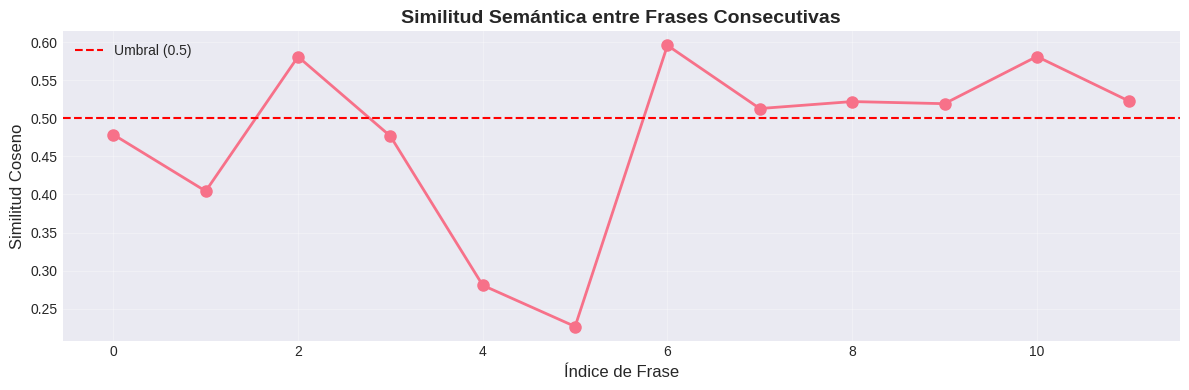


CHUNK SEMÁNTICO 1:
La inteligencia artificial (IA) es una rama de la informática que se dedica a crear sistemas capaces de realizar tareas que normalmente requieren inteligencia humana.

CHUNK SEMÁNTICO 2:
Estas tareas incluyen el reconocimiento de voz, la visión por computadora, la toma de decisiones y la traducción de idiomas.

CHUNK SEMÁNTICO 3:
El aprendizaje automático (Machine Learning) es un subcampo de la IA que permite a los sistemas aprender y mejorar automáticamente a partir de la experiencia sin ser programados explícitamente. Los algoritmos de machine learning construyen modelos matemáticos basados en datos de entrenamiento para hacer predicciones o tomar decisiones.

CHUNK SEMÁNTICO 4:
El aprendizaje profundo (Deep Learning) es un tipo especializado de machine learning que utiliza redes neuronales artificiales con múltiples capas.

CHUNK SEMÁNTICO 5:
Estas redes pueden aprender representaciones de datos con múltiples niveles de abstracción.

CHUNK SEMÁNTICO 6:
El deep le

In [8]:
# Importar modelo de embeddings
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("🔄 Cargando modelo de embeddings...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("✅ Modelo cargado")

def semantic_chunking(text: str, similarity_threshold: float = 0.5) -> List[str]:
    """
    Divide texto basándose en similitud semántica entre frases.

    Args:
        text: Texto a dividir
        similarity_threshold: Umbral de similitud para crear nuevo chunk

    Returns:
        Lista de chunks
    """
    # Dividir en frases
    sentence_endings = re.compile(r'[.?!]\s+')
    sentences = sentence_endings.split(text)
    sentences = [s.strip() for s in sentences if s.strip()]

    if len(sentences) <= 1:
        return sentences

    # Generar embeddings
    embeddings = model.encode(sentences)

    # Calcular similitudes entre frases consecutivas
    similarities = []
    for i in range(len(embeddings) - 1):
        sim = cosine_similarity([embeddings[i]], [embeddings[i + 1]])[0][0]
        similarities.append(sim)

    # Crear chunks basados en similitud
    chunks = []
    current_chunk = [sentences[0]]

    for i, sim in enumerate(similarities):
        if sim >= similarity_threshold:
            current_chunk.append(sentences[i + 1])
        else:
            chunks.append('. '.join(current_chunk) + '.')
            current_chunk = [sentences[i + 1]]

    # Agregar último chunk
    if current_chunk:
        chunks.append('. '.join(current_chunk) + '.')

    return chunks, similarities

# Aplicar chunking semántico
semantic_chunks, similarities = semantic_chunking(sample_document, similarity_threshold=0.5)

print(f"\n📊 Chunking Semántico:")
print(f"  Total de chunks: {len(semantic_chunks)}")
print(f"  Similitud promedio: {np.mean(similarities):.3f}\n")

# Visualizar similitudes
plt.figure(figsize=(12, 4))
plt.plot(similarities, marker='o', linewidth=2, markersize=8)
plt.axhline(y=0.5, color='r', linestyle='--', label='Umbral (0.5)')
plt.xlabel('Índice de Frase', fontsize=12)
plt.ylabel('Similitud Coseno', fontsize=12)
plt.title('Similitud Semántica entre Frases Consecutivas', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar chunks semánticos
for i, chunk in enumerate(semantic_chunks, 1):
    print(f"\n{'='*70}")
    print(f"CHUNK SEMÁNTICO {i}:")
    print(f"{'='*70}")
    print(chunk)

---
## Comparación de Métodos de Chunking


📋 COMPARACIÓN DE MÉTODOS DE CHUNKING
    Método  Num. Chunks  Tamaño Promedio (chars) Coherencia  Velocidad Complejidad
Caracteres           12                      190       Baja Muy Rápida        Baja
  Palabras            6                      348      Media Muy Rápida        Baja
    Frases           13                      132       Alta     Rápida       Media
  Párrafos            5                      345   Muy Alta Muy Rápida        Baja
 Semántico            6                      287   Muy Alta      Lenta        Alta


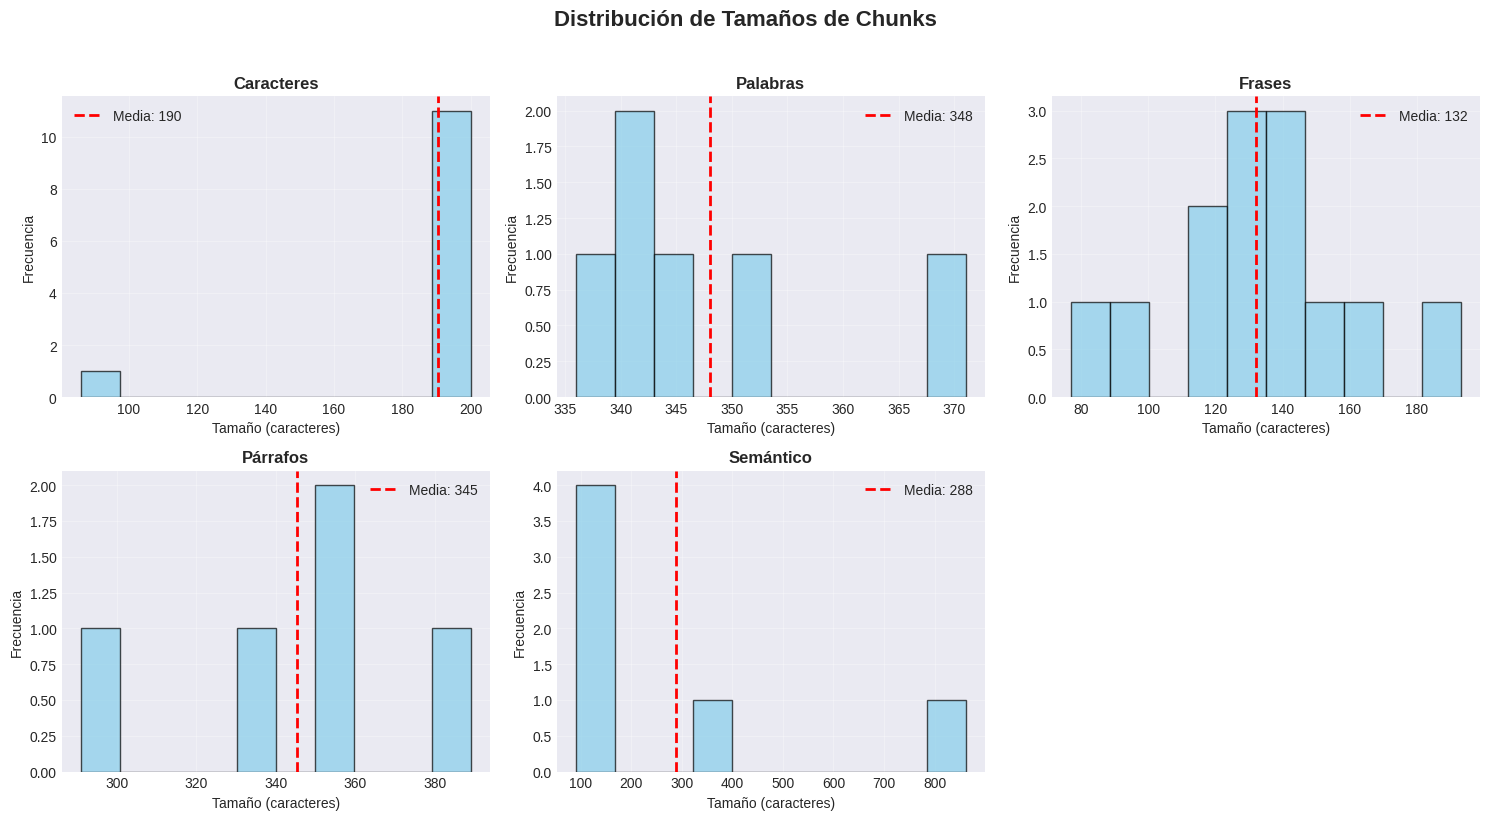

In [9]:
# Crear tabla comparativa
comparison_data = {
    'Método': ['Caracteres', 'Palabras', 'Frases', 'Párrafos', 'Semántico'],
    'Num. Chunks': [
        len(char_chunks),
        len(word_chunks),
        len(sentence_chunks),
        len(paragraph_chunks),
        len(semantic_chunks)
    ],
    'Tamaño Promedio (chars)': [
        int(np.mean([len(c) for c in char_chunks])),
        int(np.mean([len(c) for c in word_chunks])),
        int(np.mean([len(c) for c in sentence_chunks])),
        int(np.mean([len(c) for c in paragraph_chunks])),
        int(np.mean([len(c) for c in semantic_chunks]))
    ],
    'Coherencia': ['Baja', 'Media', 'Alta', 'Muy Alta', 'Muy Alta'],
    'Velocidad': ['Muy Rápida', 'Muy Rápida', 'Rápida', 'Muy Rápida', 'Lenta'],
    'Complejidad': ['Baja', 'Baja', 'Media', 'Baja', 'Alta']
}

df_comparison = pd.DataFrame(comparison_data)

print("\n" + "="*100)
print("📋 COMPARACIÓN DE MÉTODOS DE CHUNKING")
print("="*100)
print(df_comparison.to_string(index=False))
print("="*100)

# Visualización de distribución de tamaños
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

methods = [
    ('Caracteres', char_chunks),
    ('Palabras', word_chunks),
    ('Frases', sentence_chunks),
    ('Párrafos', paragraph_chunks),
    ('Semántico', semantic_chunks)
]

for idx, (name, chunks) in enumerate(methods):
    sizes = [len(c) for c in chunks]
    axes[idx].hist(sizes, bins=10, alpha=0.7, color='skyblue', edgecolor='black')
    axes[idx].axvline(np.mean(sizes), color='red', linestyle='--', linewidth=2, label=f'Media: {np.mean(sizes):.0f}')
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Tamaño (caracteres)')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

# Ocultar el subplot vacío
axes[5].axis('off')

plt.suptitle('Distribución de Tamaños de Chunks', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# PARTE 2: Bases de Datos Vectoriales

## ¿Qué son las Bases de Datos Vectoriales?

Las bases de datos vectoriales están diseñadas para almacenar y realizar búsquedas eficientes sobre vectores de alta dimensionalidad (embeddings).

### Características Clave:
1. **Búsqueda por similitud**: Encuentran vectores similares rápidamente
2. **Indexación eficiente**: Algoritmos optimizados (HNSW, IVF, etc.)
3. **Alta dimensionalidad**: Manejan vectores de 100s o 1000s de dimensiones
4. **Escalabilidad**: Millones de vectores

### Métricas de Similitud:

**1. Similitud Coseno:**
$$
\text{sim}(A, B) = \frac{A \cdot B}{||A|| \cdot ||B||} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \cdot \sqrt{\sum_{i=1}^{n} B_i^2}}
$$

**2. Distancia Euclidiana:**
$$
d(A, B) = \sqrt{\sum_{i=1}^{n} (A_i - B_i)^2}
$$

**3. Producto Punto (Dot Product):**
$$
A \cdot B = \sum_{i=1}^{n} A_i B_i
$$

---
## 📊 Generación de Embeddings

Primero, generemos embeddings para nuestros chunks usando Sentence Transformers.

In [10]:
# Usar los chunks por párrafos para el ejemplo
chunks_to_embed = sentence_chunks

print(f"🔄 Generando embeddings para {len(chunks_to_embed)} chunks...")

# Generar embeddings
embeddings = model.encode(chunks_to_embed, show_progress_bar=True)

print(f"\n✅ Embeddings generados")
print(f"Dimensiones: {embeddings.shape}")
print(f"Cada vector tiene {embeddings.shape[1]} dimensiones")

# Mostrar un ejemplo de embedding
print(f"\n📊 Ejemplo de embedding (primeras 10 dimensiones):")
print(f"Chunk 1: {embeddings[0][:10]}")
print(f"Norma L2: {np.linalg.norm(embeddings[0]):.4f}")

🔄 Generando embeddings para 13 chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Embeddings generados
Dimensiones: (13, 384)
Cada vector tiene 384 dimensiones

📊 Ejemplo de embedding (primeras 10 dimensiones):
Chunk 1: [-0.02189783  0.01467243 -0.05677896 -0.03920151 -0.0492259  -0.03218025
  0.06819402  0.02959502 -0.00552272  0.05031248]
Norma L2: 1.0000


---
## 1️⃣ FAISS (Facebook AI Similarity Search)

### Descripción:
FAISS es una biblioteca desarrollada por Facebook para búsqueda eficiente de similitud en vectores densos.

### Ventajas:
- Extremadamente rápida
- Optimizada para CPU y GPU
- Múltiples tipos de índices
- Muy escalable

### Tipos de Índices:
- **Flat**: Búsqueda exhaustiva (más precisa, más lenta)
- **IVF**: Inverted File Index (rápida, aproximada)
- **HNSW**: Hierarchical Navigable Small World (muy rápida)
- **PQ**: Product Quantization (compresión)

In [11]:
import faiss

print("🔧 Configurando FAISS...\n")

# Dimensión de los embeddings
dimension = embeddings.shape[1]

# Crear índice FAISS (Flat L2 - búsqueda exacta)
index_flat = faiss.IndexFlatL2(dimension)

# Agregar vectores al índice
index_flat.add(embeddings.astype('float32'))

print(f"✅ Índice FAISS creado")
print(f"  Tipo: IndexFlatL2 (búsqueda exacta)")
print(f"  Dimensiones: {dimension}")
print(f"  Vectores en índice: {index_flat.ntotal}")

# Función de búsqueda
def search_faiss(query: str, index, chunks, k: int = 3):
    """
    Busca los k chunks más similares a la query.

    Args:
        query: Texto de búsqueda
        index: Índice FAISS
        chunks: Lista de chunks
        k: Número de resultados

    Returns:
        Lista de (chunk, distancia, índice)
    """
    # Generar embedding de la query
    query_embedding = model.encode([query])

    # Buscar
    distances, indices = index.search(query_embedding.astype('float32'), k)

    # Preparar resultados
    results = []
    for i, (idx, dist) in enumerate(zip(indices[0], distances[0])):
        results.append({
            'rank': i + 1,
            'chunk': chunks[idx],
            'distance': dist,
            'index': idx
        })

    return results

# Probar búsqueda
query = "¿Qué es Machine Learning?"
print(f"\n🔍 Búsqueda: '{query}'\n")

results = search_faiss(query, index_flat, chunks_to_embed, k=5)

for result in results:
    print(f"{'='*70}")
    print(f"Resultado #{result['rank']} (Distancia L2: {result['distance']:.4f})")
    print(f"{'='*70}")
    print(f"{result['chunk'][:200]}")
    print()

🔧 Configurando FAISS...

✅ Índice FAISS creado
  Tipo: IndexFlatL2 (búsqueda exacta)
  Dimensiones: 384
  Vectores en índice: 13

🔍 Búsqueda: '¿Qué es Machine Learning?'

Resultado #1 (Distancia L2: 0.7463)
El aprendizaje automático (Machine Learning) es un subcampo de la IA que permite a los sistemas aprender y mejorar automáticamente a partir de la experiencia sin ser programados explícitamente.

Resultado #2 (Distancia L2: 0.8601)
Los algoritmos de machine learning construyen modelos matemáticos basados en datos de entrenamiento para hacer predicciones o tomar decisiones.

Resultado #3 (Distancia L2: 0.8951)
El deep learning ha revolucionado campos como el reconocimiento de imágenes y el procesamiento del lenguaje natural.

Resultado #4 (Distancia L2: 0.9467)
El aprendizaje profundo (Deep Learning) es un tipo especializado de machine learning que utiliza redes neuronales artificiales con múltiples capas.

Resultado #5 (Distancia L2: 1.0070)
Los LLMs han transformado la forma en que 

In [12]:
# Crear índice HNSW (más rápido para grandes datasets)
print("\n🚀 Creando índice HNSW (más eficiente)...")

# HNSW parameters
M = 32  # Número de conexiones por capa
ef_construction = 40  # Tamaño del vecindario durante construcción

index_hnsw = faiss.IndexHNSWFlat(dimension, M)
index_hnsw.hnsw.efConstruction = ef_construction
index_hnsw.add(embeddings.astype('float32'))

print(f"✅ Índice HNSW creado")
print(f"  M: {M}")
print(f"  efConstruction: {ef_construction}")
print(f"  Vectores: {index_hnsw.ntotal}")

# Comparar velocidad
import time

query_embedding = model.encode([query]).astype('float32')

# FLAT
start = time.time()
index_flat.search(query_embedding, 3)
time_flat = time.time() - start

# HNSW
start = time.time()
index_hnsw.search(query_embedding, 3)
time_hnsw = time.time() - start

print(f"\n⏱️ Comparación de velocidad:")
print(f"  Flat L2: {time_flat*1000:.4f} ms")
print(f"  HNSW: {time_hnsw*1000:.4f} ms")
print(f"  Speedup: {time_flat/time_hnsw:.2f}x")


🚀 Creando índice HNSW (más eficiente)...
✅ Índice HNSW creado
  M: 32
  efConstruction: 40
  Vectores: 13

⏱️ Comparación de velocidad:
  Flat L2: 0.0589 ms
  HNSW: 0.0482 ms
  Speedup: 1.22x


---
## 2️⃣ ChromaDB

### Descripción:
ChromaDB es una base de datos vectorial diseñada para aplicaciones de IA, con énfasis en simplicidad y facilidad de uso.

### Ventajas:
- API muy simple e intuitiva
- Persistencia integrada
- Metadata y filtrado
- Integración con LangChain
- Embeddings automáticos opcionales

### Características:
- Colecciones con metadata
- Filtrado por metadata
- Múltiples métricas de distancia
- Cliente Python/JavaScript

In [13]:
chunks_to_embed

['La inteligencia artificial (IA) es una rama de la informática que se dedica a crear sistemas capaces de realizar tareas que normalmente requieren inteligencia humana.',
 'Estas tareas incluyen el reconocimiento de voz, la visión por computadora, la toma de decisiones y la traducción de idiomas.',
 'El aprendizaje automático (Machine Learning) es un subcampo de la IA que permite a los sistemas aprender y mejorar automáticamente a partir de la experiencia sin ser programados explícitamente.',
 'Los algoritmos de machine learning construyen modelos matemáticos basados en datos de entrenamiento para hacer predicciones o tomar decisiones.',
 'El aprendizaje profundo (Deep Learning) es un tipo especializado de machine learning que utiliza redes neuronales artificiales con múltiples capas.',
 'Estas redes pueden aprender representaciones de datos con múltiples niveles de abstracción.',
 'El deep learning ha revolucionado campos como el reconocimiento de imágenes y el procesamiento del lengu

In [14]:
import chromadb
from chromadb.config import Settings

print("🔧 Configurando ChromaDB...\n")

# Crear cliente ChromaDB (en memoria)
client = chromadb.Client(Settings(
    anonymized_telemetry=False
))

from datetime import datetime
current_datetime = datetime.now()
formatted_time = current_datetime.strftime("%H-%M-%S")
# Crear o obtener colección
collection = client.create_collection(
    name=f"{formatted_time}_ai_documents",
    metadata={"description": "Documentos sobre Inteligencia Artificial"}
)

print(f"✅ Colección creada: {collection.name}")

# Preparar datos para ChromaDB
ids = [f"chunk_{i}" for i in range(len(chunks_to_embed))]
metadatas = [
    {
        "chunk_index": i,
        "chunk_length": len(chunk),
        "word_count": len(chunk.split())
    }
    for i, chunk in enumerate(chunks_to_embed)
]

# Agregar documentos con sus embeddings
collection.add(
    ids=ids,
    documents=chunks_to_embed,
    embeddings=embeddings.tolist(),
    metadatas=metadatas
)

print(f"📊 Documentos agregados: {collection.count()}")
print(f"\nMetadata de ejemplo:")
print(f"  {metadatas[0]}")

🔧 Configurando ChromaDB...

✅ Colección creada: 11-00-00_ai_documents
📊 Documentos agregados: 13

Metadata de ejemplo:
  {'chunk_index': 0, 'chunk_length': 166, 'word_count': 25}


In [15]:
# Búsqueda en ChromaDB
def search_chroma(query: str, collection, n_results: int = 3):
    """
    Busca documentos similares en ChromaDB.

    Args:
        query: Texto de búsqueda
        collection: Colección de ChromaDB
        n_results: Número de resultados

    Returns:
        Diccionario con resultados
    """
    # Generar embedding de la query
    query_embedding = model.encode([query]).tolist()

    # Buscar
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=n_results,
        include=["documents", "distances", "metadatas"]
    )

    return results

# Probar búsqueda
query = "¿Qué es Machine Learning?"
print(f"🔍 Búsqueda en ChromaDB: '{query}'\n")

results = search_chroma(query, collection, n_results=3)

for i, (doc, dist, meta) in enumerate(zip(
    results['documents'][0],
    results['distances'][0],
    results['metadatas'][0]
), 1):
    print(f"{'='*70}")
    print(f"Resultado #{i} (Distancia: {dist:.4f})")
    print(f"Metadata: {meta}")
    print(f"{'='*70}")
    print(f"{doc[:250]}")
    print()

🔍 Búsqueda en ChromaDB: '¿Qué es Machine Learning?'

Resultado #1 (Distancia: 0.7463)
Metadata: {'chunk_length': 193, 'chunk_index': 2, 'word_count': 29}
El aprendizaje automático (Machine Learning) es un subcampo de la IA que permite a los sistemas aprender y mejorar automáticamente a partir de la experiencia sin ser programados explícitamente.

Resultado #2 (Distancia: 0.8601)
Metadata: {'chunk_length': 143, 'word_count': 19, 'chunk_index': 3}
Los algoritmos de machine learning construyen modelos matemáticos basados en datos de entrenamiento para hacer predicciones o tomar decisiones.

Resultado #3 (Distancia: 0.8951)
Metadata: {'word_count': 17, 'chunk_length': 116, 'chunk_index': 6}
El deep learning ha revolucionado campos como el reconocimiento de imágenes y el procesamiento del lenguaje natural.



In [16]:
# Filtrado con metadata
print("\n🔎 Búsqueda con filtro de metadata (chunks largos):")
print(f"Filtro: chunk_length > 200 caracteres\n")

query_embedding = model.encode(["machine learning"]).tolist()

results_filtered = collection.query(
    query_embeddings=query_embedding,
    n_results=2,
    where={"chunk_length": {"$gt": 200}},
    include=["documents", "distances", "metadatas"]
)

for i, (doc, dist, meta) in enumerate(zip(
    results_filtered['documents'][0],
    results_filtered['distances'][0],
    results_filtered['metadatas'][0]
), 1):
    print(f"Resultado #{i}:")
    print(f"  Distancia: {dist:.4f}")
    print(f"  Longitud: {meta['chunk_length']} caracteres")
    print(f"  Palabras: {meta['word_count']}")
    print(f"{doc[:250]}...")
    print()


🔎 Búsqueda con filtro de metadata (chunks largos):
Filtro: chunk_length > 200 caracteres



---
## Comparación FAISS vs ChromaDB


📋 COMPARACIÓN: FAISS vs ChromaDB
  Característica            FAISS           ChromaDB
       Velocidad         Muy Alta               Alta
   Escalabilidad        Excelente              Buena
Facilidad de uso            Media           Muy Alta
    Persistencia           Manual         Automática
        Metadata        No nativo                 Sí
        Filtrado         Limitado          Excelente
     GPU Support               Sí                 No
      Mejor para Alta performance Prototipado rápido


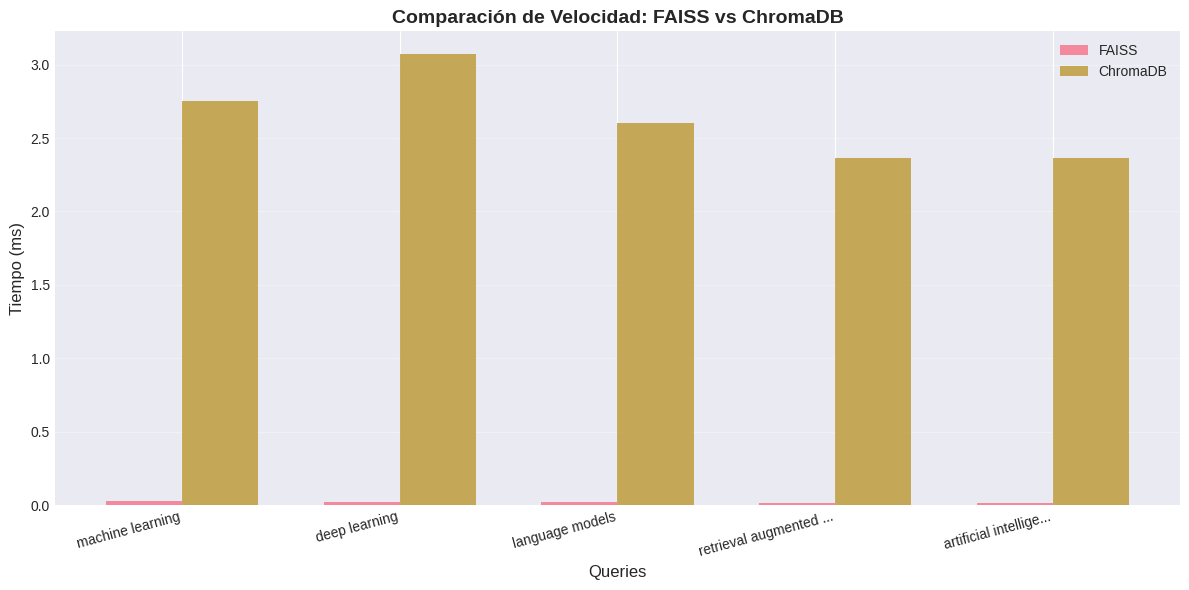


⏱️ Tiempos promedio:
  FAISS: 0.0199 ms
  ChromaDB: 2.6311 ms


In [17]:
# Tabla comparativa
comparison_data = {
    'Característica': [
        'Velocidad',
        'Escalabilidad',
        'Facilidad de uso',
        'Persistencia',
        'Metadata',
        'Filtrado',
        'GPU Support',
        'Mejor para'
    ],
    'FAISS': [
        'Muy Alta',
        'Excelente',
        'Media',
        'Manual',
        'No nativo',
        'Limitado',
        'Sí',
        'Alta performance'
    ],
    'ChromaDB': [
        'Alta',
        'Buena',
        'Muy Alta',
        'Automática',
        'Sí',
        'Excelente',
        'No',
        'Prototipado rápido'
    ]
}

df_db_comparison = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("📋 COMPARACIÓN: FAISS vs ChromaDB")
print("="*80)
print(df_db_comparison.to_string(index=False))
print("="*80)

# Visualización de tiempos de búsqueda
import time

queries = [
    "machine learning",
    "deep learning",
    "language models",
    "retrieval augmented generation",
    "artificial intelligence"
]

faiss_times = []
chroma_times = []

for query in queries:
    # FAISS
    query_emb = model.encode([query]).astype('float32')
    start = time.time()
    index_flat.search(query_emb, 3)
    faiss_times.append((time.time() - start) * 1000)

    # ChromaDB
    start = time.time()
    search_chroma(query, collection, n_results=3)
    chroma_times.append((time.time() - start) * 1000)

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(queries))
width = 0.35

bars1 = ax.bar(x - width/2, faiss_times, width, label='FAISS', alpha=0.8)
bars2 = ax.bar(x + width/2, chroma_times, width, label='ChromaDB', alpha=0.8)

ax.set_xlabel('Queries', fontsize=12)
ax.set_ylabel('Tiempo (ms)', fontsize=12)
ax.set_title('Comparación de Velocidad: FAISS vs ChromaDB', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([q[:20] + '...' if len(q) > 20 else q for q in queries], rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n⏱️ Tiempos promedio:")
print(f"  FAISS: {np.mean(faiss_times):.4f} ms")
print(f"  ChromaDB: {np.mean(chroma_times):.4f} ms")

---
# Ejemplo Completo: Pipeline RAG

Combinemos todo lo aprendido en un pipeline completo.

In [18]:
class SimpleRAGPipeline:
    """
    Pipeline simple de RAG que integra chunking y búsqueda vectorial.
    """

    def __init__(self, model_name='all-MiniLM-L6-v2', use_faiss=True):
        self.model = SentenceTransformer(model_name)
        self.use_faiss = use_faiss
        self.chunks = []
        self.embeddings = None
        self.index = None
        self.collection = None

    def process_document(self, text: str, chunk_method='paragraph'):
        """
        Procesa un documento: chunking + embedding + indexing.
        """
        print(f"📄 Procesando documento ({len(text)} caracteres)...")

        # 1. Chunking
        if chunk_method == 'paragraph':
            self.chunks = chunk_by_paragraphs(text)
        elif chunk_method == 'sentence':
            self.chunks = chunk_by_sentences(text, max_sentences=1)
        elif chunk_method == 'semantic':
            self.chunks, _ = semantic_chunking(text)

        print(f"  ✓ Creados {len(self.chunks)} chunks")

        # 2. Embeddings
        print(f"  🔄 Generando embeddings...")
        self.embeddings = self.model.encode(self.chunks, show_progress_bar=False)
        print(f"  ✓ Embeddings generados ({self.embeddings.shape})")

        # 3. Indexing
        if self.use_faiss:
            dimension = self.embeddings.shape[1]
            self.index = faiss.IndexFlatL2(dimension)
            self.index.add(self.embeddings.astype('float32'))
            print(f"  ✓ Índice FAISS creado")
        else:
            client = chromadb.Client(Settings(anonymized_telemetry=False))
            self.collection = client.create_collection(name="rag_docs")
            self.collection.add(
                ids=[f"chunk_{i}" for i in range(len(self.chunks))],
                documents=self.chunks,
                embeddings=self.embeddings.tolist()
            )
            print(f"  ✓ Colección ChromaDB creada")

        print(f"\n✅ Documento procesado e indexado")

    def search(self, query: str, k: int = 3):
        """
        Busca los k chunks más relevantes.
        """
        query_embedding = self.model.encode([query])

        if self.use_faiss:
            distances, indices = self.index.search(query_embedding.astype('float32'), k)
            results = []
            for idx, dist in zip(indices[0], distances[0]):
                results.append({
                    'chunk': self.chunks[idx],
                    'score': float(dist),
                    'index': int(idx)
                })
        else:
            chroma_results = self.collection.query(
                query_embeddings=query_embedding.tolist(),
                n_results=k
            )
            results = []
            for doc, dist in zip(chroma_results['documents'][0], chroma_results['distances'][0]):
                results.append({
                    'chunk': doc,
                    'score': float(dist),
                    'index': -1
                })

        return results

    def generate_context(self, query: str, k: int = 3):
        """
        Genera contexto para una query (para pasar a un LLM).
        """
        results = self.search(query, k=k)
        context = "\n\n".join([r['chunk'] for r in results])
        return context, results

# Crear pipeline
print("\n" + "="*70)
print("🚀 PIPELINE RAG COMPLETO")
print("="*70 + "\n")

# Usar FAISS
rag_pipeline_faiss = SimpleRAGPipeline(use_faiss=True)
rag_pipeline_faiss.process_document(sample_document, chunk_method='sentence')

# Probar búsqueda
query = "¿Cómo funciona RAG?"
print(f"\n🔍 Query: '{query}'\n")

context, results = rag_pipeline_faiss.generate_context(query, k=5)

print(f"📊 Resultados encontrados: {len(results)}\n")
for i, result in enumerate(results, 1):
    print(f"{'─'*70}")
    print(f"Resultado #{i} (Score: {result['score']:.4f})")
    print(f"{'─'*70}")
    print(result['chunk'])
    print()

print(f"\n{'='*70}")
print(f"CONTEXTO GENERADO (para LLM)")
print(f"{'='*70}")
print(context)
print(f"{'='*70}")


🚀 PIPELINE RAG COMPLETO

📄 Procesando documento (1736 caracteres)...
  ✓ Creados 13 chunks
  🔄 Generando embeddings...
  ✓ Embeddings generados ((13, 384))
  ✓ Índice FAISS creado

✅ Documento procesado e indexado

🔍 Query: '¿Cómo funciona RAG?'

📊 Resultados encontrados: 5

──────────────────────────────────────────────────────────────────────
Resultado #1 (Score: 1.0776)
──────────────────────────────────────────────────────────────────────
RAG primero busca información relevante en una base de datos y luego usa esa información para generar respuestas más precisas y fundamentadas.

──────────────────────────────────────────────────────────────────────
Resultado #2 (Score: 1.2377)
──────────────────────────────────────────────────────────────────────
La generación aumentada por recuperación (RAG) es una técnica que combina la recuperación de información con modelos de lenguaje.

──────────────────────────────────────────────────────────────────────
Resultado #3 (Score: 1.3127)
──────

---
### Chunking:
1. **Tamaño de chunk**: Balance entre contexto y precisión
   - Muy pequeños: Pierden contexto
   - Muy grandes: Menos precisos
   - Recomendado: 200-500 tokens

2. **Overlap**: Ayuda a preservar contexto entre chunks
   - Recomendado: 10-20% del tamaño del chunk

3. **Método**: Depende del tipo de documento
   - Documentos estructurados → Por párrafos
   - Texto continuo → Por frases o semántico
   - Conversaciones → Por turno



### Bases de Datos Vectoriales:

**Usa FAISS cuando:**
- Necesitas máxima velocidad
- Trabajas con millones de vectores
- Tienes GPU disponible
- La metadata no es crítica

**Usa ChromaDB cuando:**
- Prototipas rápidamente
- Necesitas metadata rica
- Requieres filtrado complejo
- La facilidad de uso es prioritaria



## Recursos Adicionales

- FAISS Documentation: https://faiss.ai/
- ChromaDB Docs: https://docs.trychroma.com/
- Sentence Transformers: https://www.sbert.net/
- LangChain (para RAG): https://python.langchain.com/